In this notebook we'll set the values of the Main RIV Cond IDF to NA inside the Chaamse Beek catchment.

# 0. Imports

In [5]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
from pathlib import Path
import imod
from rasterio.features import geometry_mask

In [14]:
from WS_Mdl.core import *
from WS_Mdl.imod.xr import clip_Mdl_Aa

# 1. Options

In [ ]:
MdlN = "NBr54"

In [ ]:
Pa_IDF = r"G:\models\NBr\In\RIV\RIV_Cond_DRN_NBr1.idf"
Pa_boundary = r"G:\models\NBr\PoP\common\Pgn\Chaamse_beek\catchment_chaamsebeek_ulvenhout.shp"

In [4]:
Pa_Out = rf"G:\models\NBr\In\RIV\{MdlN}\RIV_Cond_Main_DRN_{MdlN}.idf"

In [8]:
# 2. Load IDF and boundary

In [10]:
DA = imod.idf.open(Pa_IDF)

Could not determine imod version from Sim/NBr54 folder.
Proceeding with the assumption that it's imod_python.


🟢 - INI file G:\models\NBr\code\Mdl_Prep\Mdl_Prep_NBr54.ini read successfully. Dictionary created with 21 keys.
Clipping xarray data to model area: X=[113100.0, 125100.0], Y=[387600.0, 396200.0]
Y coordinates in descending order, using slice(Ymax, Ymin)
🟢🟢 - Successfully clipped xarray data to model area


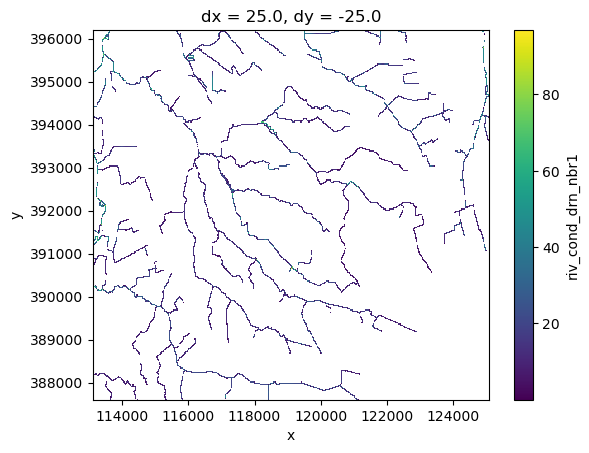

In [15]:
clip_Mdl_Aa(DA, MdlN).plot()

In [16]:
# read polygon
gdf = gpd.read_file(Pa_boundary)

In [17]:
# create mask (True inside polygon)
mask = geometry_mask(
    gdf.geometry,
    transform=DA.rio.transform(),
    invert=True,
    out_shape=(DA.sizes["y"], DA.sizes["x"]),
)

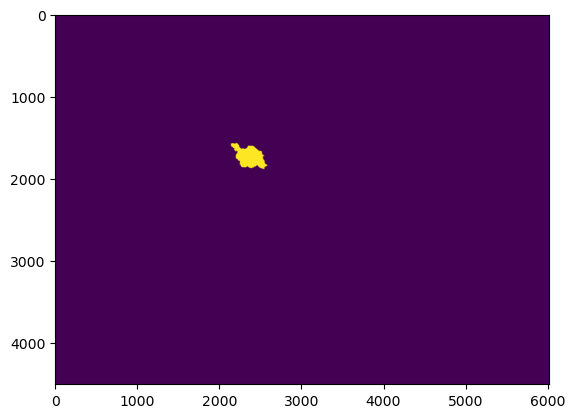

In [22]:
import matplotlib.pyplot as plt
plt.imshow(mask)

In [23]:
# apply mask → inside polygon becomes NaN
DA_masked = DA.where(~mask)

In [27]:
# save as IDF
imod.idf.write(Path(Pa_Out).with_suffix(".idf"), DA_masked, nodata=-999.9900)